## Imports & Load Cleaned Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Load the cleaned dataset from Phase 1
DATA_PATH = '../data/processed/uac_cleaned.csv'

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Add time helper columns
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['YearMon'] = df['Date'].dt.to_period('M')
df['Weekday'] = df['Date'].dt.day_name()

print(f"Dataset loaded: {df.shape}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Columns: {list(df.columns)}")


Dataset loaded: (720, 11)
Date range: 2023-01-12 → 2025-12-21
Columns: ['Date', 'CBP_Apprehended', 'CBP_Custody', 'CBP_Transferred', 'HHS_Care', 'HHS_Discharged', 'Year', 'Month', 'Weekday', 'Date_Gap', 'YearMon']


## Engineer All 5 KPIs 


In [5]:
# KPI 1: Transfer Efficiency Ratio
# How fast is CBP moving children to HHS?
df['Transfer_Efficiency'] = (
    df['CBP_Transferred'] / df['CBP_Custody'].replace(0, np.nan)
).round(4)

# KPI 2: Discharge Effectiveness Index
# How well is HHS completing sponsor placements each day?
df['Discharge_Effectiveness'] = (
    df['HHS_Discharged'] / df['HHS_Care'].replace(0, np.nan)
).round(4)

# KPI 3: Pipeline Throughput Rate
# Are total exits keeping pace with total entries?
df['Pipeline_Throughput'] = (
    (df['CBP_Transferred'] + df['HHS_Discharged']) /
    (df['CBP_Apprehended'] + df['HHS_Care']).replace(0, np.nan)
).round(4)

# KPI 4: Backlog Accumulation
# Net children stuck in the system on any given day
df['Backlog'] = (
    df['CBP_Apprehended'] - df['CBP_Transferred'] +
    df['HHS_Care']        - df['HHS_Discharged']
)

# KPI 5: Outcome Stability Score
# 30-day rolling std dev of discharge effectiveness
# Low = consistent placements, High = volatile performance
df['Outcome_Stability'] = (
    df['Discharge_Effectiveness'].rolling(window=30).std()
).round(4)

# Rolling 30-day averages for smoother trend lines
df['TE_30d'] = df['Transfer_Efficiency'].rolling(30).mean().round(4)
df['DE_30d'] = df['Discharge_Effectiveness'].rolling(30).mean().round(4)
df['PT_30d'] = df['Pipeline_Throughput'].rolling(30).mean().round(4)

# Print KPI summary
print("=== KPI ENGINEERING COMPLETE ===\n")
print("New columns added:")
kpi_cols = ['Transfer_Efficiency', 'Discharge_Effectiveness',
            'Pipeline_Throughput', 'Backlog', 'Outcome_Stability']
for kpi in kpi_cols:
    print(f"  {kpi}")

print("\n=== KPI SUMMARY STATISTICS ===\n")
print(df[kpi_cols].describe().round(4))

print("\n=== SAMPLE — First 3 rows with KPIs ===")
print(df[['Date'] + kpi_cols].head(3))

=== KPI ENGINEERING COMPLETE ===

New columns added:
  Transfer_Efficiency
  Discharge_Effectiveness
  Pipeline_Throughput
  Backlog
  Outcome_Stability

=== KPI SUMMARY STATISTICS ===

       Transfer_Efficiency  Discharge_Effectiveness  Pipeline_Throughput  \
count             720.0000                 720.0000             720.0000   
mean                0.6910                   0.0237               0.0412   
std                 0.3098                   0.0133               0.0222   
min                 0.0000                   0.0000               0.0025   
25%                 0.5000                   0.0086               0.0140   
50%                 0.7044                   0.0263               0.0484   
75%                 0.8464                   0.0329               0.0581   
max                 2.3000                   0.0664               0.0838   

          Backlog  Outcome_Stability  
count    720.0000           691.0000  
mean    5852.7236             0.0060  
std     2698

## Monthly KPI Trend Chart 


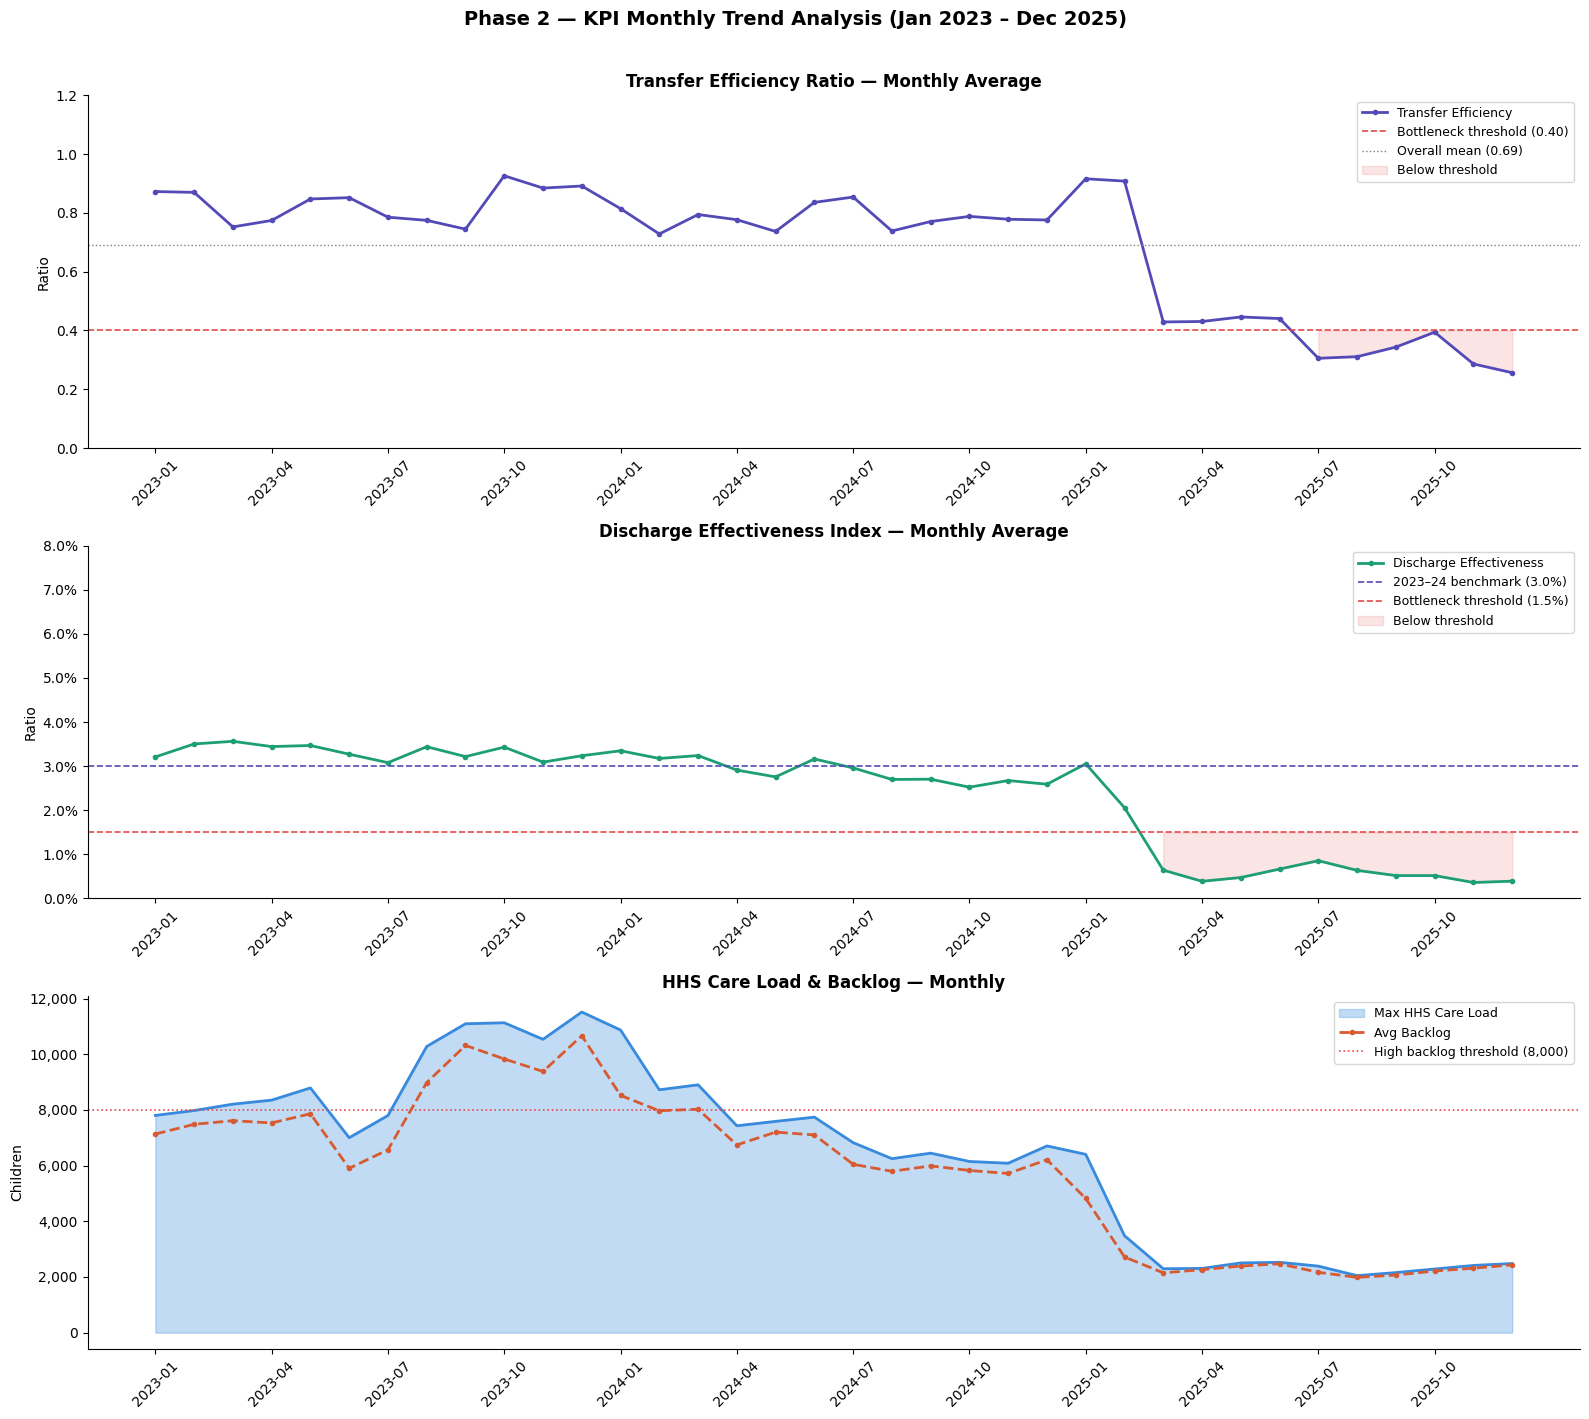

Monthly KPI trend chart saved!


In [7]:
# Group by Year-Month
monthly = df.groupby('YearMon').agg(
    Avg_TE=('Transfer_Efficiency', 'mean'),
    Avg_DE=('Discharge_Effectiveness', 'mean'),
    Avg_PT=('Pipeline_Throughput', 'mean'),
    Avg_Backlog=('Backlog', 'mean'),
    Max_HHS_Care=('HHS_Care', 'max')
).reset_index()

monthly['YearMon_str'] = monthly['YearMon'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# --- Plot 1: Transfer Efficiency ---
ax1 = axes[0]
ax1.plot(monthly['YearMon_str'], monthly['Avg_TE'],
         color='#534AB7', linewidth=2, marker='o', markersize=3, label='Transfer Efficiency')
ax1.axhline(0.40, color='#E24B4A', linestyle='--', linewidth=1.2, label='Bottleneck threshold (0.40)')
ax1.axhline(monthly['Avg_TE'].mean(), color='gray', linestyle=':', linewidth=1, label=f'Overall mean ({monthly["Avg_TE"].mean():.2f})')
ax1.fill_between(monthly['YearMon_str'], monthly['Avg_TE'], 0.40,
                  where=monthly['Avg_TE'] < 0.40,
                  color='#E24B4A', alpha=0.15, label='Below threshold')
ax1.set_title('Transfer Efficiency Ratio — Monthly Average', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ratio', fontsize=10)
ax1.set_ylim(0, 1.2)
ax1.legend(fontsize=9)
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticks(ax1.get_xticks()[::3])

# --- Plot 2: Discharge Effectiveness ---
ax2 = axes[1]
ax2.plot(monthly['YearMon_str'], monthly['Avg_DE'],
         color='#1D9E75', linewidth=2, marker='o', markersize=3, label='Discharge Effectiveness')
ax2.axhline(0.030, color='#534AB7', linestyle='--', linewidth=1.2, label='2023–24 benchmark (3.0%)')
ax2.axhline(0.015, color='#E24B4A', linestyle='--', linewidth=1.2, label='Bottleneck threshold (1.5%)')
ax2.fill_between(monthly['YearMon_str'], monthly['Avg_DE'], 0.015,
                  where=monthly['Avg_DE'] < 0.015,
                  color='#E24B4A', alpha=0.15, label='Below threshold')
ax2.set_title('Discharge Effectiveness Index — Monthly Average', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ratio', fontsize=10)
ax2.set_ylim(0, 0.08)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=45)
ax2.set_xticks(ax2.get_xticks()[::3])

# --- Plot 3: HHS Care Load & Backlog ---
ax3 = axes[2]
ax3.fill_between(monthly['YearMon_str'], monthly['Max_HHS_Care'],
                  color='#378ADD', alpha=0.3, label='Max HHS Care Load')
ax3.plot(monthly['YearMon_str'], monthly['Max_HHS_Care'],
         color='#378ADD', linewidth=2)
ax3.plot(monthly['YearMon_str'], monthly['Avg_Backlog'],
         color='#D85A30', linewidth=2, linestyle='--', marker='o', markersize=3,
         label='Avg Backlog')
ax3.axhline(8000, color='#E24B4A', linestyle=':', linewidth=1.2,
            label='High backlog threshold (8,000)')
ax3.set_title('HHS Care Load & Backlog — Monthly', fontsize=12, fontweight='bold')
ax3.set_ylabel('Children', fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax3.legend(fontsize=9)
ax3.tick_params(axis='x', rotation=45)
ax3.set_xticks(ax3.get_xticks()[::3])

fig.suptitle('Phase 2 — KPI Monthly Trend Analysis (Jan 2023 – Dec 2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/charts/03_monthly_kpi_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Monthly KPI trend chart saved!")

### Year-over-Year KPI Comparison 


=== YEAR-OVER-YEAR KPI TABLE ===

Year                               2023        2024       2025
Avg_Transfer_Efficiency          0.8300      0.7834     0.4603
Avg_Discharge_Effectiveness      0.0334      0.0290     0.0090
Avg_Pipeline_Throughput          0.0512      0.0577     0.0143
Avg_Backlog                   8318.6304   6775.7291  2510.3264
Peak_Backlog                 11139.0000  10579.0000  6192.0000
Avg_Outcome_Stability            0.0070      0.0067     0.0042
Total_Discharged             66244.0000  51689.0000  6920.0000
Total_Apprehended            27056.0000  37166.0000  3115.0000


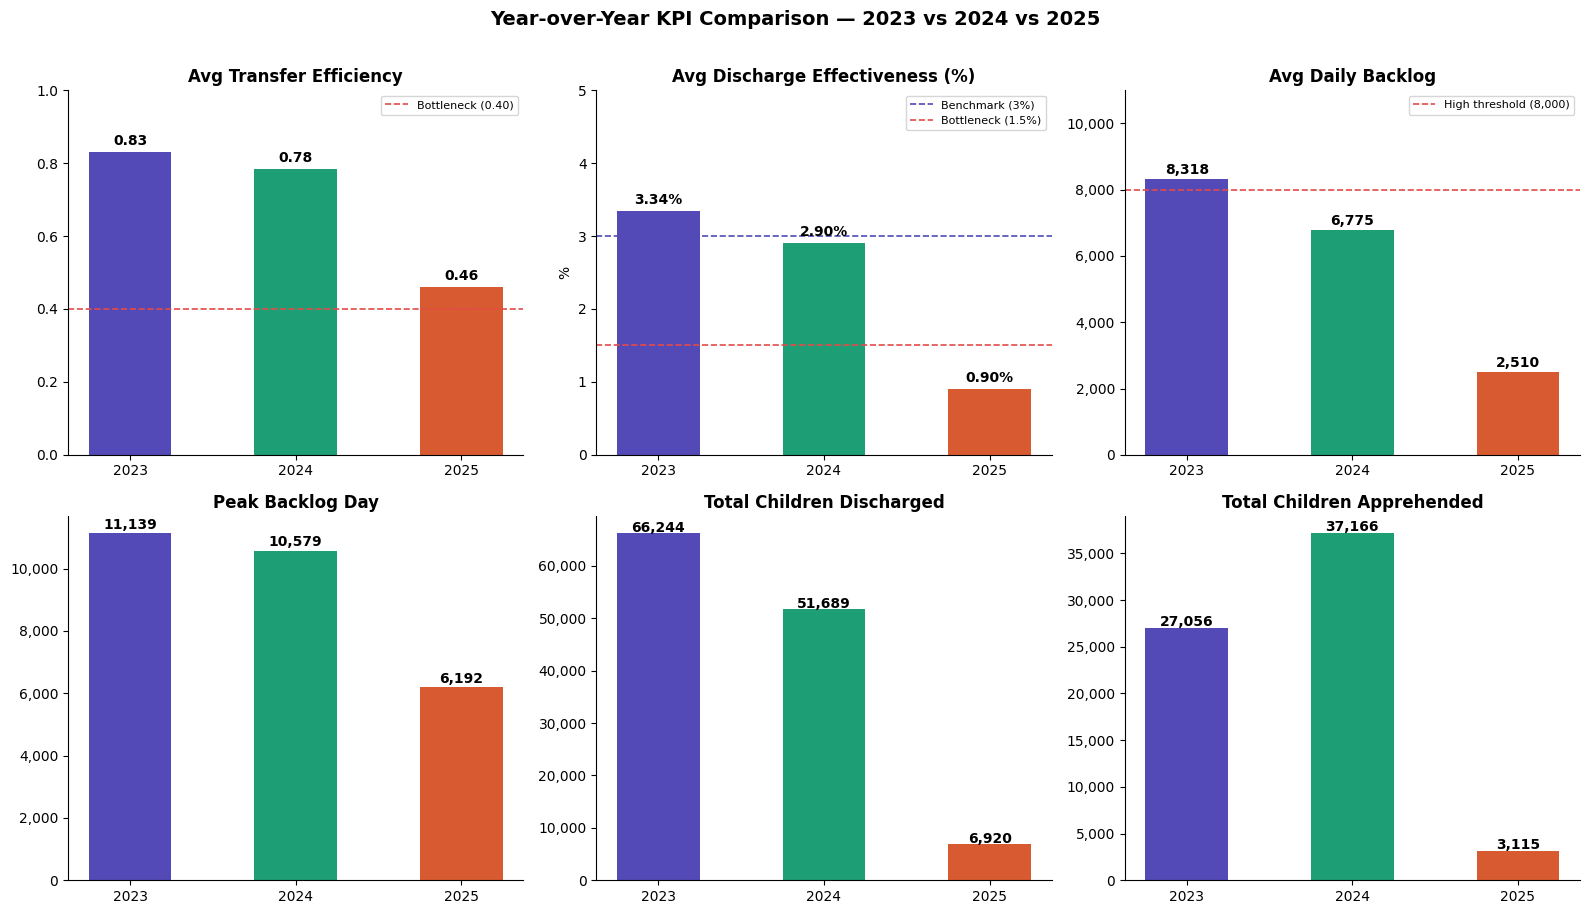

Year-over-year comparison chart saved!


In [9]:
yoy = df.groupby('Year').agg(
    Avg_Transfer_Efficiency   = ('Transfer_Efficiency',    'mean'),
    Avg_Discharge_Effectiveness = ('Discharge_Effectiveness', 'mean'),
    Avg_Pipeline_Throughput   = ('Pipeline_Throughput',    'mean'),
    Avg_Backlog               = ('Backlog',                'mean'),
    Peak_Backlog              = ('Backlog',                'max'),
    Avg_Outcome_Stability     = ('Outcome_Stability',      'mean'),
    Total_Discharged          = ('HHS_Discharged',         'sum'),
    Total_Apprehended         = ('CBP_Apprehended',        'sum')
).round(4)

print("=== YEAR-OVER-YEAR KPI TABLE ===\n")
print(yoy.T)

# ── Chart ────────────────────────────────────────────────────────
years  = [2023, 2024, 2025]
colors = ['#534AB7', '#1D9E75', '#D85A30']
labels = ['2023', '2024', '2025']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Plot 1 — Avg Transfer Efficiency
axes[0].bar(labels, yoy['Avg_Transfer_Efficiency'], color=colors, width=0.5)
axes[0].axhline(0.40, color='#E24B4A', linestyle='--', linewidth=1.2, label='Bottleneck (0.40)')
axes[0].set_title('Avg Transfer Efficiency', fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=8)
for i, v in enumerate(yoy['Avg_Transfer_Efficiency']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Plot 2 — Avg Discharge Effectiveness
axes[1].bar(labels, yoy['Avg_Discharge_Effectiveness'] * 100, color=colors, width=0.5)
axes[1].axhline(3.0, color='#534AB7', linestyle='--', linewidth=1.2, label='Benchmark (3%)')
axes[1].axhline(1.5, color='#E24B4A', linestyle='--', linewidth=1.2, label='Bottleneck (1.5%)')
axes[1].set_title('Avg Discharge Effectiveness (%)', fontweight='bold')
axes[1].set_ylim(0, 5)
axes[1].set_ylabel('%')
axes[1].legend(fontsize=8)
for i, v in enumerate(yoy['Avg_Discharge_Effectiveness'] * 100):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Plot 3 — Avg Backlog
axes[2].bar(labels, yoy['Avg_Backlog'], color=colors, width=0.5)
axes[2].axhline(8000, color='#E24B4A', linestyle='--', linewidth=1.2, label='High threshold (8,000)')
axes[2].set_title('Avg Daily Backlog', fontweight='bold')
axes[2].set_ylim(0, 11000)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[2].legend(fontsize=8)
for i, v in enumerate(yoy['Avg_Backlog']):
    axes[2].text(i, v + 150, f'{int(v):,}', ha='center', fontsize=10, fontweight='bold')

# Plot 4 — Peak Backlog
axes[3].bar(labels, yoy['Peak_Backlog'], color=colors, width=0.5)
axes[3].set_title('Peak Backlog Day', fontweight='bold')
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(yoy['Peak_Backlog']):
    axes[3].text(i, v + 150, f'{int(v):,}', ha='center', fontsize=10, fontweight='bold')

# Plot 5 — Total Discharged
axes[4].bar(labels, yoy['Total_Discharged'], color=colors, width=0.5)
axes[4].set_title('Total Children Discharged', fontweight='bold')
axes[4].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(yoy['Total_Discharged']):
    axes[4].text(i, v + 200, f'{int(v):,}', ha='center', fontsize=10, fontweight='bold')

# Plot 6 — Total Apprehended
axes[5].bar(labels, yoy['Total_Apprehended'], color=colors, width=0.5)
axes[5].set_title('Total Children Apprehended', fontweight='bold')
axes[5].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(yoy['Total_Apprehended']):
    axes[5].text(i, v + 200, f'{int(v):,}', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Year-over-Year KPI Comparison — 2023 vs 2024 vs 2025',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/charts/04_yoy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Year-over-year comparison chart saved!")

## Weekday Pattern Analysis 

=== WEEKDAY KPI PATTERN ===

           Avg_Transfer_Efficiency  Avg_Discharge_Effectiveness  \
Weekday                                                           
Monday                      0.6605                       0.0217   
Tuesday                     0.6705                       0.0187   
Wednesday                   0.6920                       0.0226   
Thursday                    0.7326                       0.0279   
Sunday                      0.7001                       0.0284   

           Avg_Pipeline_Throughput  Avg_Backlog  Count  
Weekday                                                 
Monday                      0.0385    5876.0069    145  
Tuesday                     0.0358    5918.5772    149  
Wednesday                   0.0403    5954.9456    147  
Thursday                    0.0459    5884.3810    147  
Sunday                      0.0463    5627.0538    130  


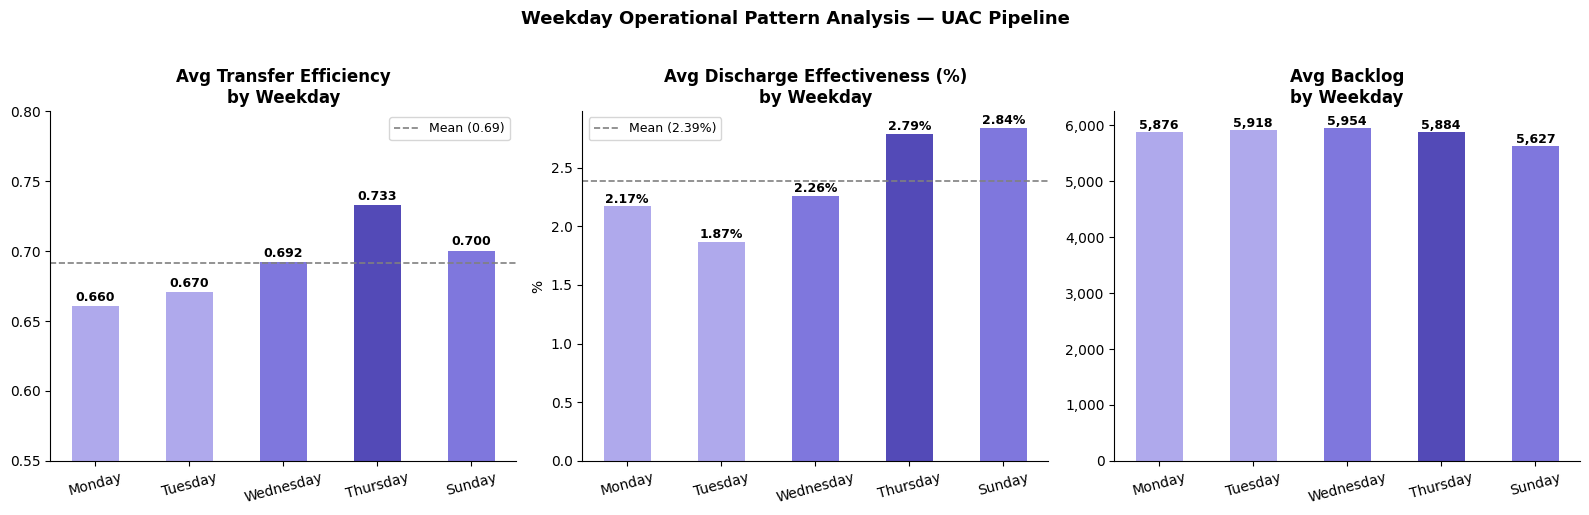

Weekday pattern chart saved!


In [12]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Sunday']

wd = df[df['Weekday'].isin(weekday_order)].groupby('Weekday').agg(
    Avg_Transfer_Efficiency    = ('Transfer_Efficiency',    'mean'),
    Avg_Discharge_Effectiveness= ('Discharge_Effectiveness','mean'),
    Avg_Pipeline_Throughput    = ('Pipeline_Throughput',    'mean'),
    Avg_Backlog                = ('Backlog',                'mean'),
    Count                      = ('Date',                   'count')
).reindex(weekday_order).round(4)

print("=== WEEKDAY KPI PATTERN ===\n")
print(wd)

# ── Chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bar_colors = ['#AFA9EC', '#AFA9EC', '#7F77DD', '#534AB7', '#7F77DD']

# Plot 1 — Transfer Efficiency by Weekday
axes[0].bar(weekday_order, wd['Avg_Transfer_Efficiency'],
            color=bar_colors, width=0.5)
axes[0].axhline(wd['Avg_Transfer_Efficiency'].mean(),
                color='gray', linestyle='--', linewidth=1.2,
                label=f'Mean ({wd["Avg_Transfer_Efficiency"].mean():.2f})')
axes[0].set_title('Avg Transfer Efficiency\nby Weekday', fontweight='bold')
axes[0].set_ylim(0.55, 0.80)
axes[0].legend(fontsize=9)
for i, v in enumerate(wd['Avg_Transfer_Efficiency']):
    axes[0].text(i, v + 0.004, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2 — Discharge Effectiveness by Weekday
axes[1].bar(weekday_order, wd['Avg_Discharge_Effectiveness'] * 100,
            color=bar_colors, width=0.5)
axes[1].axhline(wd['Avg_Discharge_Effectiveness'].mean() * 100,
                color='gray', linestyle='--', linewidth=1.2,
                label=f'Mean ({wd["Avg_Discharge_Effectiveness"].mean()*100:.2f}%)')
axes[1].set_title('Avg Discharge Effectiveness (%)\nby Weekday', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=9)
for i, v in enumerate(wd['Avg_Discharge_Effectiveness'] * 100):
    axes[1].text(i, v + 0.03, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 3 — Avg Backlog by Weekday
axes[2].bar(weekday_order, wd['Avg_Backlog'],
            color=bar_colors, width=0.5)
axes[2].set_title('Avg Backlog\nby Weekday', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(wd['Avg_Backlog']):
    axes[2].text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Weekday Operational Pattern Analysis — UAC Pipeline',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/charts/05_weekday_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("Weekday pattern chart saved!")

## Bottleneck Detection 

=== BOTTLENECK DETECTION SUMMARY ===

Total days analysed           : 720
Days with backlog > 8000     : 182
Days with transfer eff < 0.4  : 129
Days with discharge eff < 0.015: 204
Days with ANY bottleneck      : 393
Bottleneck % of all days      : 54.6%

=== BOTTLENECK DAYS BY YEAR ===
Year
2023    130
2024     55
2025    208
Name: Any_Bottleneck, dtype: int64

=== TOP 10 WORST BACKLOG DAYS ===
      Date  CBP_Apprehended  HHS_Care  HHS_Discharged  Backlog  Transfer_Efficiency  Discharge_Effectiveness
2023-12-20            136.0     11516           390.0  11139.0               0.5000                   0.0339
2023-12-19            105.0     11291           272.0  10966.0               0.8541                   0.0241
2023-12-26             56.0     11217           288.0  10917.0               0.8293                   0.0257
2023-12-27             74.0     11206           335.0  10865.0               0.7767                   0.0299
2023-12-28             68.0     11230           357.0  

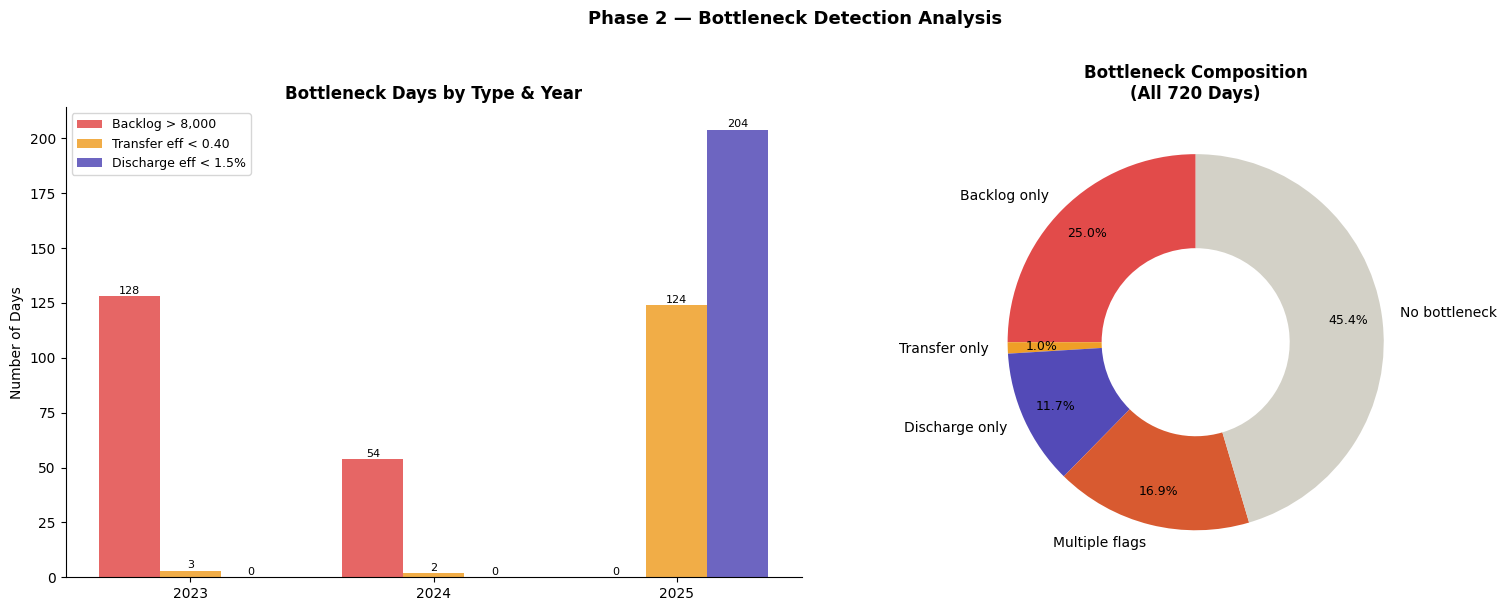

Bottleneck detection chart saved!


In [15]:
# Define thresholds
BACKLOG_THRESH   = 8000   # Children in HHS care
TE_LOW_THRESH    = 0.40   # Transfer efficiency
DE_LOW_THRESH    = 0.015  # Discharge effectiveness

# Flag bottleneck days
df['Bottleneck_Backlog']   = df['HHS_Care']              > BACKLOG_THRESH
df['Bottleneck_Transfer']  = df['Transfer_Efficiency']   < TE_LOW_THRESH
df['Bottleneck_Discharge'] = df['Discharge_Effectiveness'] < DE_LOW_THRESH
df['Any_Bottleneck']       = (df['Bottleneck_Backlog'] |
                               df['Bottleneck_Transfer'] |
                               df['Bottleneck_Discharge'])

# Summary
print("=== BOTTLENECK DETECTION SUMMARY ===\n")
print(f"Total days analysed           : {len(df)}")
print(f"Days with backlog > {BACKLOG_THRESH}     : {df['Bottleneck_Backlog'].sum()}")
print(f"Days with transfer eff < {TE_LOW_THRESH}  : {df['Bottleneck_Transfer'].sum()}")
print(f"Days with discharge eff < {DE_LOW_THRESH}: {df['Bottleneck_Discharge'].sum()}")
print(f"Days with ANY bottleneck      : {df['Any_Bottleneck'].sum()}")
print(f"Bottleneck % of all days      : {df['Any_Bottleneck'].mean()*100:.1f}%")

print("\n=== BOTTLENECK DAYS BY YEAR ===")
print(df.groupby('Year')['Any_Bottleneck'].sum())

print("\n=== TOP 10 WORST BACKLOG DAYS ===")
top_backlog = df.nlargest(10, 'Backlog')[['Date','CBP_Apprehended',
                                          'HHS_Care','HHS_Discharged',
                                          'Backlog','Transfer_Efficiency',
                                          'Discharge_Effectiveness']]
print(top_backlog.to_string(index=False))

# ── Chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Bottleneck days by type and year
bottleneck_yearly = df.groupby('Year').agg(
    Backlog_Days   = ('Bottleneck_Backlog',   'sum'),
    Transfer_Days  = ('Bottleneck_Transfer',  'sum'),
    Discharge_Days = ('Bottleneck_Discharge', 'sum')
)

x      = np.arange(3)
width  = 0.25
years  = ['2023', '2024', '2025']

axes[0].bar(x - width, bottleneck_yearly['Backlog_Days'],
            width, label='Backlog > 8,000', color='#E24B4A', alpha=0.85)
axes[0].bar(x,          bottleneck_yearly['Transfer_Days'],
            width, label='Transfer eff < 0.40', color='#EF9F27', alpha=0.85)
axes[0].bar(x + width,  bottleneck_yearly['Discharge_Days'],
            width, label='Discharge eff < 1.5%', color='#534AB7', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(years)
axes[0].set_title('Bottleneck Days by Type & Year', fontweight='bold')
axes[0].set_ylabel('Number of Days')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (b, t, d) in enumerate(zip(bottleneck_yearly['Backlog_Days'],
                                    bottleneck_yearly['Transfer_Days'],
                                    bottleneck_yearly['Discharge_Days'])):
    axes[0].text(i - width, b + 1, str(int(b)), ha='center', fontsize=8)
    axes[0].text(i,          t + 1, str(int(t)), ha='center', fontsize=8)
    axes[0].text(i + width,  d + 1, str(int(d)), ha='center', fontsize=8)

# Plot 2 — Donut chart of bottleneck composition across all years
backlog_only  = df[ df['Bottleneck_Backlog'] & ~df['Bottleneck_Transfer'] & ~df['Bottleneck_Discharge']].shape[0]
transfer_only = df[~df['Bottleneck_Backlog'] &  df['Bottleneck_Transfer'] & ~df['Bottleneck_Discharge']].shape[0]
discharge_only= df[~df['Bottleneck_Backlog'] & ~df['Bottleneck_Transfer'] &  df['Bottleneck_Discharge']].shape[0]
multiple      = df['Any_Bottleneck'].sum() - backlog_only - transfer_only - discharge_only
no_bottleneck = len(df) - df['Any_Bottleneck'].sum()

sizes  = [backlog_only, transfer_only, discharge_only, multiple, no_bottleneck]
labels = ['Backlog only', 'Transfer only', 'Discharge only', 'Multiple flags', 'No bottleneck']
colors = ['#E24B4A', '#EF9F27', '#534AB7', '#D85A30', '#D3D1C7']

wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', pctdistance=0.82,
    wedgeprops=dict(width=0.5),
    startangle=90
)
for t in autotexts:
    t.set_fontsize(9)

axes[1].set_title('Bottleneck Composition\n(All 720 Days)', fontweight='bold')

fig.suptitle('Phase 2 — Bottleneck Detection Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/charts/06_bottleneck_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bottleneck detection chart saved!")

## Stagnation Period Detection

=== STAGNATION PERIOD DETECTION ===

Threshold     : HHS Care daily change < 20 children
Min duration  : 7 consecutive days
Periods found : 9

     Start        End  Duration  Avg_HHS_Care  Avg_Discharge_Eff
2025-03-10 2025-03-27        14        2128.0             0.0038
2025-03-31 2025-05-01        25        2271.0             0.0039
2025-06-02 2025-06-17         8        2514.0             0.0058
2025-07-22 2025-08-07        13        2068.0             0.0068
2025-08-11 2025-08-28        14        1987.0             0.0064
2025-09-02 2025-09-10         7        2022.0             0.0055
2025-09-22 2025-10-09        14        2163.0             0.0061
2025-10-14 2025-11-06        18        2262.0             0.0048
2025-12-01 2025-12-11         9        2427.0             0.0037


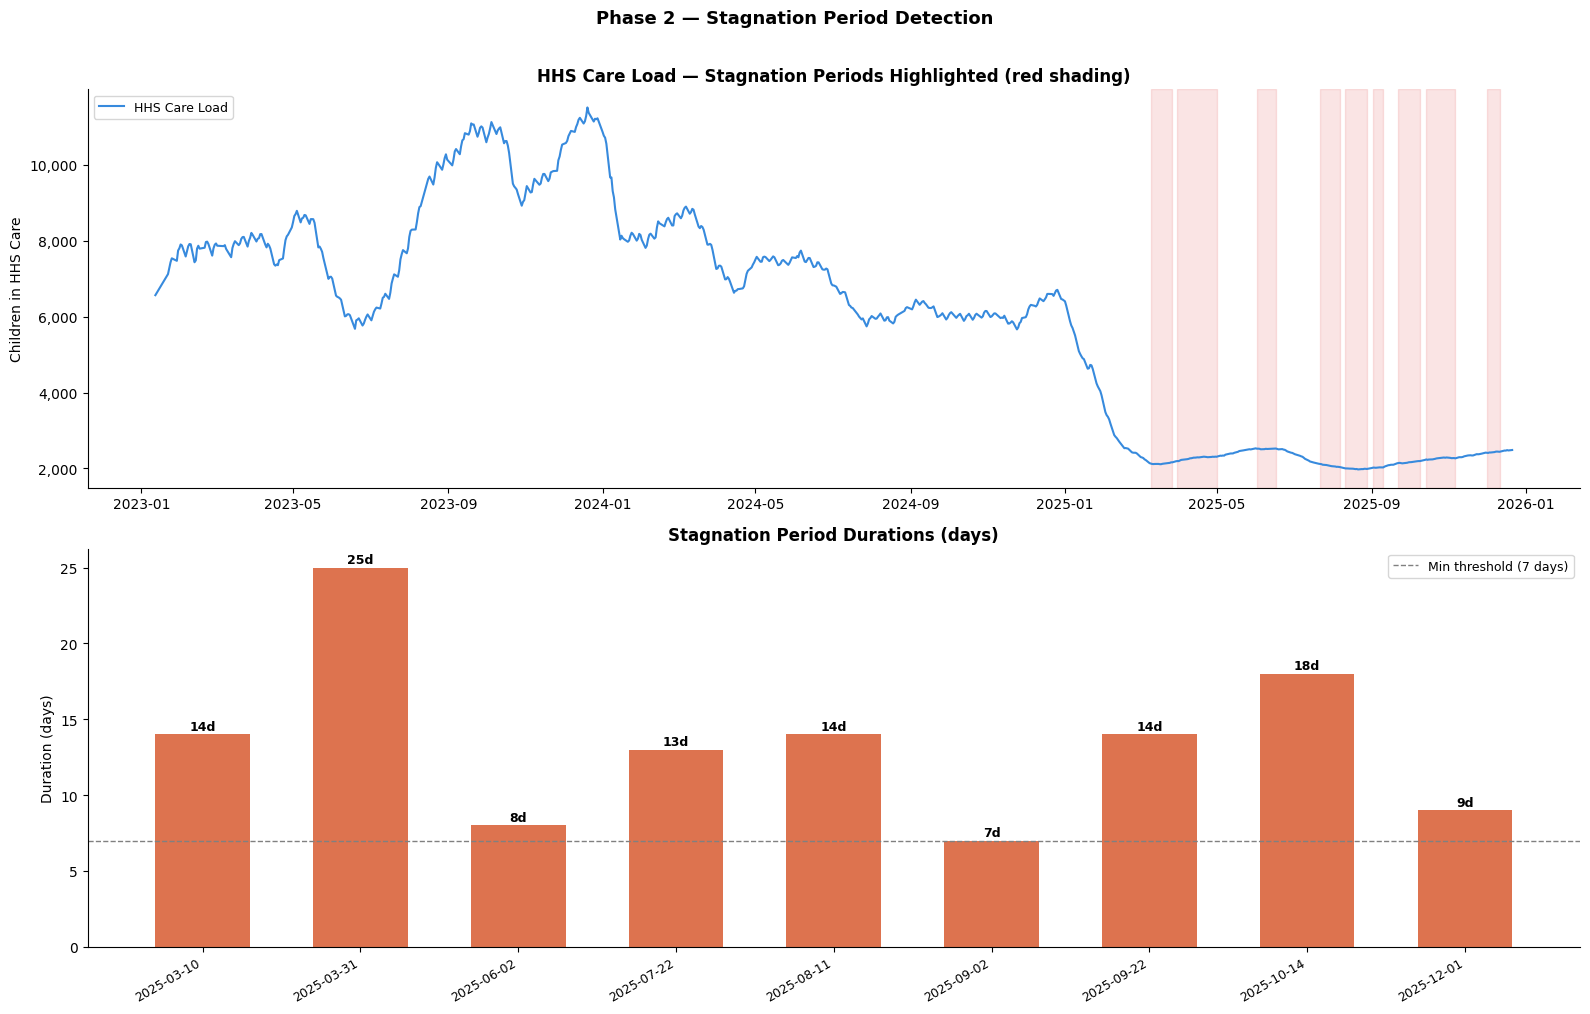

Stagnation period chart saved!


In [18]:
# A stagnation period = HHS Care load barely moving for 7+ consecutive days
# Threshold: daily change in HHS Care < 20 children

STAGNATION_THRESHOLD = 20
MIN_DURATION         = 7

df['HHS_Care_Change'] = df['HHS_Care'].diff().abs()
df['Is_Stagnant']     = df['HHS_Care_Change'] < STAGNATION_THRESHOLD

# Detect consecutive stagnation runs
stagnation_periods = []
count, start_idx = 0, None

for i, val in enumerate(df['Is_Stagnant']):
    if val:
        if count == 0:
            start_idx = i
        count += 1
    else:
        if count >= MIN_DURATION:
            stagnation_periods.append({
                'Start'      : df.loc[start_idx, 'Date'].date(),
                'End'        : df.loc[i - 1,     'Date'].date(),
                'Duration'   : count,
                'Avg_HHS_Care': df.loc[start_idx:i-1, 'HHS_Care'].mean().round(0),
                'Avg_Discharge_Eff': df.loc[start_idx:i-1, 'Discharge_Effectiveness'].mean().round(4)
            })
        count = 0

# Catch last run
if count >= MIN_DURATION:
    stagnation_periods.append({
        'Start'      : df.loc[start_idx, 'Date'].date(),
        'End'        : df.loc[len(df)-1,  'Date'].date(),
        'Duration'   : count,
        'Avg_HHS_Care': df.loc[start_idx:, 'HHS_Care'].mean().round(0),
        'Avg_Discharge_Eff': df.loc[start_idx:, 'Discharge_Effectiveness'].mean().round(4)
    })

stag_df = pd.DataFrame(stagnation_periods)

print("=== STAGNATION PERIOD DETECTION ===\n")
print(f"Threshold     : HHS Care daily change < {STAGNATION_THRESHOLD} children")
print(f"Min duration  : {MIN_DURATION} consecutive days")
print(f"Periods found : {len(stag_df)}\n")
print(stag_df.to_string(index=False))

# ── Chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1 — HHS Care load with stagnation periods shaded
axes[0].plot(df['Date'], df['HHS_Care'],
             color='#378ADD', linewidth=1.5, label='HHS Care Load')

for _, row in stag_df.iterrows():
    axes[0].axvspan(pd.Timestamp(row['Start']),
                    pd.Timestamp(row['End']),
                    color='#E24B4A', alpha=0.15)

axes[0].set_title('HHS Care Load — Stagnation Periods Highlighted (red shading)',
                  fontweight='bold')
axes[0].set_ylabel('Children in HHS Care')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(fontsize=9)

# Plot 2 — Stagnation duration bar chart
if len(stag_df) > 0:
    x_labels = [f"{row['Start']}" for _, row in stag_df.iterrows()]
    axes[1].bar(range(len(stag_df)), stag_df['Duration'],
                color='#D85A30', alpha=0.85, width=0.6)
    axes[1].set_xticks(range(len(stag_df)))
    axes[1].set_xticklabels(x_labels, rotation=30, ha='right', fontsize=9)
    axes[1].set_title('Stagnation Period Durations (days)',fontweight='bold')
    axes[1].set_ylabel('Duration (days)')
    axes[1].axhline(MIN_DURATION, color='gray', linestyle='--',
                    linewidth=1, label=f'Min threshold ({MIN_DURATION} days)')
    axes[1].legend(fontsize=9)
    for i, row in stag_df.iterrows():
        axes[1].text(i, row['Duration'] + 0.3,
                     f"{row['Duration']}d", ha='center',
                     fontsize=9, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Phase 2 — Stagnation Period Detection',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/charts/07_stagnation_periods.png', dpi=150, bbox_inches='tight')
plt.show()

print("Stagnation period chart saved!")

## Save Final Engineered Dataset & Phase 2 Summary:

In [22]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save the fully engineered dataset
df.to_csv('../data/processed/uac_engineered.csv', index=False)

print("Engineered dataset saved to ../data/processed/uac_engineered.csv")
print(f"   Shape  : {df.shape}")
print(f"   Columns: {list(df.columns)}")

Engineered dataset saved to ../data/processed/uac_engineered.csv
   Shape  : (720, 25)
   Columns: ['Date', 'CBP_Apprehended', 'CBP_Custody', 'CBP_Transferred', 'HHS_Care', 'HHS_Discharged', 'Year', 'Month', 'Weekday', 'Date_Gap', 'YearMon', 'Transfer_Efficiency', 'Discharge_Effectiveness', 'Pipeline_Throughput', 'Backlog', 'Outcome_Stability', 'TE_30d', 'DE_30d', 'PT_30d', 'Bottleneck_Backlog', 'Bottleneck_Transfer', 'Bottleneck_Discharge', 'Any_Bottleneck', 'HHS_Care_Change', 'Is_Stagnant']


## Phase 2 — KPI Engineering & Analysis: Key Findings

### KPIs Engineered
| KPI | Formula | Overall Mean |
|---|---|---|
| Transfer Efficiency Ratio | CBP_Transferred ÷ CBP_Custody | 0.69 |
| Discharge Effectiveness Index | HHS_Discharged ÷ HHS_Care | 2.37% |
| Pipeline Throughput Rate | (Transfers + Discharges) ÷ (Apprehended + HHS Care) | 4.12% |
| Backlog Accumulation | CBP_Apprehended − CBP_Transferred + HHS_Care − HHS_Discharged | 5,853 |
| Outcome Stability Score | 30-day rolling std dev of Discharge Effectiveness | 0.006 |

### Year-over-Year Findings
| KPI | 2023 | 2024 | 2025 |
|---|---|---|---|
| Avg Transfer Efficiency | 0.83 | 0.78 | 0.46 |
| Avg Discharge Effectiveness | 3.34% | 2.90% | 0.90% |
| Avg Daily Backlog | 8,318 | 6,775 | 2,510 |
| Total Children Discharged | 66,244 | 51,689 | 6,920 |
| Total Children Apprehended | 27,056 | 37,166 | 3,115 |

### Bottleneck Detection
- **393 out of 720 days (54.6%)** triggered at least one bottleneck flag
- 2023: dominated by **backlog days** (128) — system overwhelmed
- 2025: dominated by **discharge failure days** (204) — pipeline frozen
- 2025: **124 days** of critically low transfer efficiency — 72-hour rule frequently breached

### Stagnation Periods
- **9 stagnation periods detected — all in 2025**
- Longest: 25 consecutive days (Mar 31 → May 1, 2025)
- Total frozen days: 122 out of 239 reporting days in 2025 (51%)

### Weekday Patterns
- **Thursday** is consistently the best performing day 
  (Transfer efficiency: 0.733, Discharge effectiveness: 2.79%)
- **Tuesday** is the weakest day for discharge effectiveness (1.87%)
- Backlog is stable across weekdays — driven by year, not day of week
```
